In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, BatchNormalization
from keras.regularizers import l2
import keras
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.utils import resample
import tensorflow as tf
import seaborn as sns
import random
import shap
from scipy.optimize import differential_evolution

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

df_predictors = pd.read_excel('/content/Extended Data_predictors.xlsx')
print(df_predictors.shape)
print(df_predictors.head())

df_target = pd.read_excel('/content/Extended Data_response.xlsx')
print(df_target.shape)
print(df_target.head())

df_full = df_predictors.copy()
df_full['Kc'] = df_target['Kc']

print(df_full.head())

# Проверка на пропуски
print(f"\nПропуски в данных:\n{df_full.isnull().sum()}")

# Разделение 80/20
train_df, test_df = train_test_split(df_full, test_size=0.2, stratify=df_full['P'], random_state=42)

print(f"Обучающая выборка: {len(train_df)} строк (80%)")
print(f"Тестовая выборка: {len(test_df)} строк (20%)")

# Отделяем предикторы (X) от целевой переменной (y)
X_train = train_df[['a', 'c', 'P']].values
y_train = train_df['Kc'].values

X_test = test_df[['a', 'c', 'P']].values
y_test = test_df['Kc'].values

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

(30000, 4)
           a      c        P       c/a
0  15.630000  49.05  27.3715  3.138196
1  15.860152  49.05  27.3715  3.092656
2  16.090303  49.05  27.3715  3.048420
3  16.320455  49.05  27.3715  3.005431
4  16.550606  49.05  27.3715  2.963638
(30000, 1)
         Kc
0  0.735192
1  0.757003
2  0.779132
3  0.801581
4  0.824348
           a      c        P       c/a        Kc
0  15.630000  49.05  27.3715  3.138196  0.735192
1  15.860152  49.05  27.3715  3.092656  0.757003
2  16.090303  49.05  27.3715  3.048420  0.779132
3  16.320455  49.05  27.3715  3.005431  0.801581
4  16.550606  49.05  27.3715  2.963638  0.824348

Пропуски в данных:
a      0
c      0
P      0
c/a    0
Kc     0
dtype: int64
Обучающая выборка: 24000 строк (80%)
Тестовая выборка: 6000 строк (20%)
Обучающая выборка: (24000, 3)
Тестовая выборка: (6000, 3)


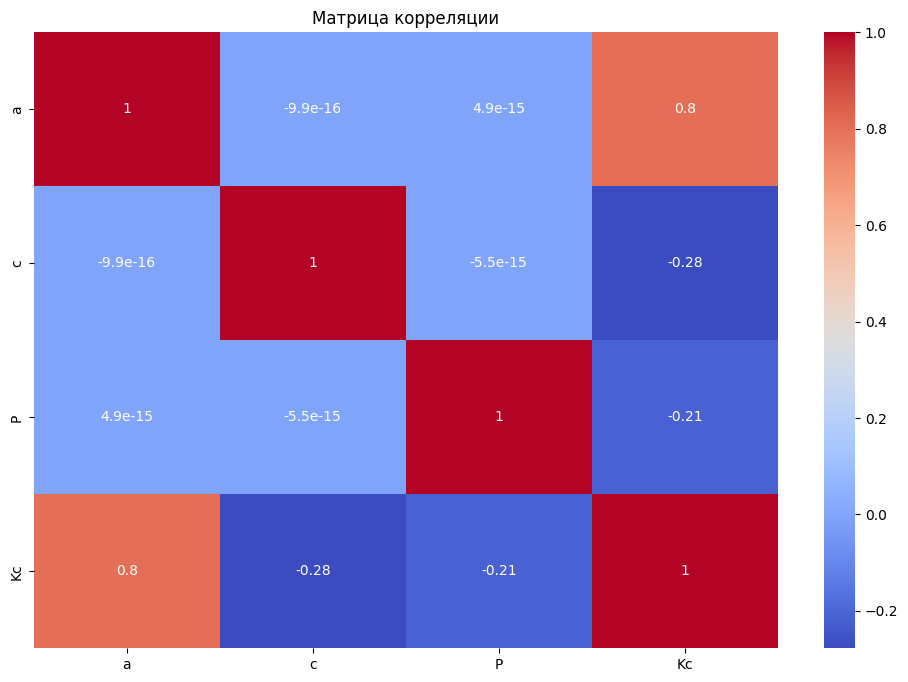

In [ ]:
df = df_full.drop(columns=['c/a'])
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Матрица корреляции')
plt.show()

In [ ]:
# Набор стратегий для K-Fold кросс-валидации
strategies = [
    {'name': 'A', 'layers': 3, 'neurons': 64, 'activation': 'tanh'},
    {'name': 'B', 'layers': 2, 'neurons': 64, 'activation': 'relu'},
    {'name': 'C', 'layers': 3, 'neurons': 32, 'activation': 'tanh'},
    {'name': 'D', 'layers': 2, 'neurons': 32, 'activation': 'relu'},
    {'name': 'E', 'layers': 3, 'neurons': 64, 'activation': 'relu'}
]

In [ ]:
# Функция для создания модели
def build_model(layers, neurons, activation, learning_rate=0.001):
    model = Sequential()

    model.add(Dense(neurons, activation=activation, input_shape=(3,), kernel_regularizer=l2(0.00001)))
    model.add(BatchNormalization())

    for _ in range(layers - 1):
        model.add(Dense(neurons, activation=activation, kernel_regularizer=l2(0.00001)))
        model.add(BatchNormalization())

    model.add(Dense(1, activation='linear'))  # регрессия

    model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate))

    return model

In [ ]:
np.random.seed(SEED)
tf.random.set_seed(SEED)

# K-Fold кросс-валидация
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

results = []

for strategy in strategies: # Провекра всех гиперпараметров
    print(f"\nПроверяем стратегию {strategy['name']}...")

    fold_mse = []
    fold_mae = []
    fold_r2 = []

    for train_idx, val_idx in kf.split(X_train): # Разделение выборки
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_val = scaler.transform(X_val)

        model = build_model(
            strategy['layers'],
            strategy['neurons'],
            strategy['activation']
        )

        model.fit(X_tr, y_tr, epochs=40, batch_size=64, verbose=0)

        y_pred = model.predict(X_val, verbose=0)
        mse = mean_squared_error(y_val, y_pred)
        mae = mean_absolute_error(y_val, y_pred)
        r2 = r2_score(y_val, y_pred)

        fold_mse.append(mse)
        fold_mae.append(mae)
        fold_r2.append(r2)

    avg_mse = np.mean(fold_mse)
    avg_mae = np.mean(fold_mae)
    avg_r2 = np.mean(fold_r2)

# Добавление модели и ее результатов в словарь
    results.append({
        'name': strategy['name'],
        'layers': strategy['layers'],
        'neurons': strategy['neurons'],
        'activation': strategy['activation'],
        'mean_mse': avg_mse
    })

    print(f"MSE: {avg_mse:.4f}")
    print(f"MAE: {avg_mae:.4f}")
    print(f"R2: {avg_r2:.4f}")


Проверяем стратегию A...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

MSE: 0.0056
MAE: 0.0500
R2: 0.9529

Проверяем стратегию B...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

MSE: 0.0030
MAE: 0.0378
R2: 0.9751

Проверяем стратегию C...


...

MSE: 0.0047
MAE: 0.0461
R2: 0.9603

Проверяем стратегию D...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

MSE: 0.0024
MAE: 0.0320
R2: 0.9798

Проверяем стратегию E...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

MSE: 0.0023
MAE: 0.0313
R2: 0.9808


In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='mean_mse') # Сортировка по среднему MSE

print("\nВсе стратегии:")
print(results_df)

print("\nЛУЧШАЯ СТРАТЕГИЯ:")
print(results_df.iloc[0])


Все стратегии:
  name  layers  neurons activation  mean_mse
4    E       3       64       relu  0.002289
3    D       2       32       relu  0.002415
1    B       2       64       relu  0.002978
2    C       3       32       tanh  0.004740
0    A       3       64       tanh  0.005622

ЛУЧШАЯ СТРАТЕГИЯ:
name                 E
layers               3
neurons             64
activation        relu
mean_mse      0.002289
Name: 4, dtype: object


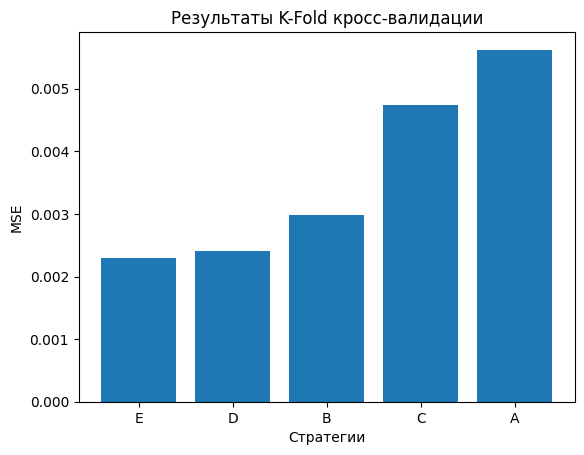

In [ ]:
plt.bar(results_df['name'], results_df['mean_mse'])
plt.title('Результаты K-Fold кросс-валидации')
plt.xlabel('Стратегии')
plt.ylabel('MSE')
plt.show()

In [ ]:
# Масштабирование
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
np.random.seed(SEED)
tf.random.set_seed(SEED)

value = df_full['P'].unique() # Значения пористости
n_models = 10
models = []
mse_list = []
X_testm = []
y_testm = []

# Разбиение выборки по разной пористости
for i in value:
    df_test = test_df[test_df['P'] == i].copy()

    X_test1 = df_test[['a', 'c', 'P']].values
    X_test1 = scaler.transform(X_test1)

    X_testm.append(X_test1)
    y_testm.append(df_test['Kc'].values)

# Обучение 10 нейронных сетей
for i in range(n_models):
    print(f"Модель {i+1}")

    X_boot, y_boot = resample(X_train, y_train, replace=True, random_state=SEED+i) # Создание бутстрап-выборки

    model = build_model(int(results_df.iloc[0, 1]), int(results_df.iloc[0, 2]), results_df.iloc[0, 3]) # Создание модели с лучшими гиперпараметрами

    model.fit(X_boot, y_boot, epochs=40, batch_size=64, verbose=0)

    mse_con = []
    mae_con = []
    r2_con = []

    for i in range(3): # Предсказание для разной пористости
        y_pred = model.predict(X_testm[i], verbose=0)

        mse_con.append(mean_squared_error(y_testm[i], y_pred))
        mae_con.append(mean_absolute_error(y_testm[i], y_pred))
        r2_con.append(r2_score(y_testm[i], y_pred))
        print(f"mse({value[i]}): {mse_con[i]:.6f}")

    mse = np.mean(mse_con)
    mae = np.mean(mae_con)
    r2 = np.mean(r2_con)
    models.append(model)
    mse_list.append(mse)

    print(f"MSE: {mse:.6f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")

Модель 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


mse(27.3715): 0.001056
mse(23.01): 0.000874
mse(7.96274): 0.002903
MSE: 0.001611
MAE: 0.0260
R2: 0.9863
Модель 2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


mse(27.3715): 0.002729
mse(23.01): 0.002049
mse(7.96274): 0.001834
MSE: 0.002204
MAE: 0.0372
R2: 0.9792
Модель 3


...

mse(27.3715): 0.000825
mse(23.01): 0.000963
mse(7.96274): 0.002095
MSE: 0.001294
MAE: 0.0232
R2: 0.9889
Модель 9


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


mse(27.3715): 0.000900
mse(23.01): 0.001258
mse(7.96274): 0.004384
MSE: 0.002180
MAE: 0.0358
R2: 0.9821
Модель 10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


mse(27.3715): 0.000787
mse(23.01): 0.001108
mse(7.96274): 0.001869
MSE: 0.001255
MAE: 0.0197
R2: 0.9892


In [ ]:
# Выявление 5 лучших моделей
best_indices = np.argsort(mse_list)[:5]
best_models = [models[i] for i in best_indices]

mse = []
mae = []
r2 = []
mse_data = []

# Предсказание на 5 лучших моделях и объединение их в ансамбль
for i in range(3):
    pred_con = []

    for model in best_models:
        pred = model.predict(X_testm[i], verbose=0)
        mse_data.append(mean_squared_error(y_testm[i], pred))
        pred_con.append(pred)

    predictions = np.mean(pred_con, axis=0)
    mse.append(mean_squared_error(y_testm[i], predictions))
    mae.append(mean_absolute_error(y_testm[i], predictions))
    r2.append(r2_score(y_testm[i], predictions))
    print(f"MSE({value[i]}): {mse[i]:.6f}")

ensemble_mse = np.mean(mse)
ensemble_mae = np.mean(mae)
ensemble_r2 = np.mean(r2)

print(f"Ансамбль MSE: {ensemble_mse:.6f}")
print(f"Ансамбль MAE: {ensemble_mae:.6f}")
print(f"Ансамбль R2: {ensemble_r2:.6f}")

MSE(27.3715): 0.000351
MSE(23.01): 0.000554
MSE(7.96274): 0.001054
Ансамбль MSE: 0.000653
Ансамбль MAE: 0.012028
Ансамбль R2: 0.994440


In [ ]:
data = []

# Построение датафрейма с результатами моделей
for i in range(5):
    j = (mse_data[i] + mse_data[i+5] + mse_data[i+10])/3
    data.append({"Модель": best_indices[i]+1,
            "0.0%": mse_data[i],
            "0.1%": mse_data[i+5],
            "0.5%": mse_data[i+10],
            "MSE": j})

result_df = pd.DataFrame(data)
print(result_df)

   Модель      0.0%      0.1%      0.5%       MSE
0       5  0.000444  0.001076  0.002244  0.001254
1      10  0.000787  0.001108  0.001869  0.001255
2       8  0.000825  0.000963  0.002095  0.001294
3       6  0.001137  0.001422  0.001487  0.001349
4       4  0.000762  0.001006  0.002559  0.001442


In [ ]:
# Формирование новой выборки для прогнозирования поверхностей K_IC (P,a,c) для концентраций МУНТ от 0.0 до 0.5 масс.%
MWCNT_con = np.arange(0, 0.51, 0.01)
P_con = np.linspace(max(value), min(value), len(MWCNT_con))
a = np.linspace(15.63, 38.415, 100)
c = np.linspace(49.05, 108.24, 100)

data = []
for i in P_con:
    for j in c:
        for n in a:
            data.append({"a": n,
                    "c": j,
                    "P": i})

new_X = pd.DataFrame(data)

new_X1 = scaler.transform(new_X)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [ ]:
ensemble_pred = []
pred_mean = []

# Предсказание модлей на новой выборке
for model in best_models:
    pred = model.predict(new_X1, verbose=0)
    predictions = []
    for i in P_con:
        df_test = new_X.copy()
        df_test['Kc'] = pred
        df_test = df_test[df_test['P'] == i].copy()
        q = df_test['Kc'].values

        predictions.append(np.mean(q))

    pred_mean.append(predictions)

ensemble_pred = np.mean(pred_mean, axis=0)

hg = []

# Расчет исходных экспериментальных данных
for i in value:
    df_test = df_full.copy()
    df_test = df_test[df_test['P'] == i].copy()
    hg.append(np.mean(df_test['Kc'].values))

In [ ]:
pred_array = np.array(pred_mean)

# Среднее и стандартное отклонение по моделям в каждой точке x
ensemble_mean = np.mean(pred_array, axis=0)
ensemble_std  = np.std(pred_array, axis=0)

# 95% доверительный интервал
z = 1.96  # для 95% CI
ci_lower = ensemble_mean - z * ensemble_std
ci_upper = ensemble_mean + z * ensemble_std

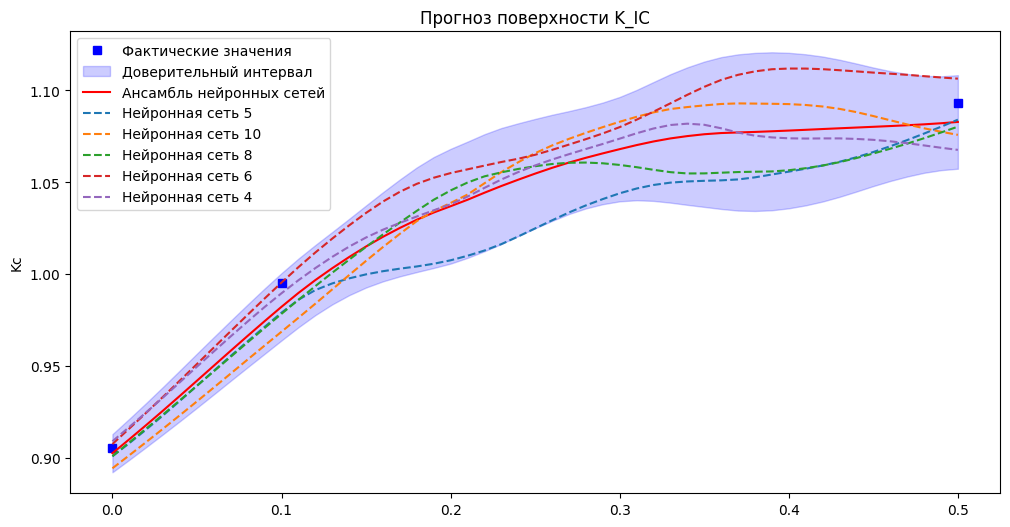

In [ ]:
# Построение графиков
plt.figure(figsize=(12, 6))
x_points = MWCNT_con
y_points = ensemble_pred
x_points1 = [0, 0.1, 0.5]
y_points1 = hg

# Фактические точки
plt.plot(x_points1, y_points1, marker ='s', linestyle ='', color='blue', label='Фактические значения')

# Доверительный интервал
plt.fill_between(x_points, ci_lower, ci_upper, color='blue', alpha=0.2, label='Доверительный интервал')

# Ансамбль
plt.plot(x_points, y_points, color='red', label='Ансамбль нейронных сетей')

# Отдельные модели
for i in range(5):
    plt.plot(x_points, pred_mean[i], linestyle ='--', label=f'Нейронная сеть {best_indices[i]+1}')
plt.ylabel('Kc')
plt.title('Прогноз поверхности K_IC')
plt.legend()
plt.show()

In [ ]:
# Известные соответствия
P_to_MWCNT = {
    27.3715 : 0.0,
    23.01   : 0.1,
    7.96274 : 0.5
}

MWCNT_to_P = {v: k for k, v in P_to_MWCNT.items()}

# Интерполяция для промежуточных значений
from scipy.interpolate import interp1d

mwcnt_values = np.array([0.0, 0.1, 0.5])
p_values     = np.array([27.3715, 23.01, 7.96274])

# P убывает с ростом концентрации МУНТ
mwcnt_to_p_interp = interp1d(mwcnt_values, p_values,
                              kind='linear',
                              fill_value='extrapolate')

p_to_mwcnt_interp = interp1d(p_values[::-1], mwcnt_values[::-1],
                              kind='linear',
                              fill_value='extrapolate')

In [ ]:
def ensemble_predict(P, a_mean, c_mean, scaler, models):
    data = []

    for j in c_mean:
        for n in a_mean:
            data.append({"a": n,
                    "c": j,
                    "P": P})

    x = pd.DataFrame(data)

    # масштабирование
    x_scaled = scaler.transform(x)

    predictions = []
    # предсказание сети
    for model in models:
        preds = model.predict(x_scaled, verbose=0)

        predictions.append(np.mean(preds))

    return np.mean(predictions), np.std(predictions)

def objective(mwcnt, target_kic, a_mean, c_mean, scaler, models):
    # Оптимизация по концентрации МУНТ, P вычисляем из неё
    P = float(mwcnt_to_p_interp(mwcnt[0]))  # концентрация → пористость
    kic_pred, _ = ensemble_predict(P, a_mean, c_mean, scaler, models)
    return (kic_pred - target_kic) ** 2

def concentration_calc(target_kic, scaler, models, df_full):

    a = np.linspace(15.63, 38.415, 100)
    c = np.linspace(49.05, 108.24, 100)

    print(f"ЦЕЛЕВАЯ ТРЕЩИНОСТОЙКОСТЬ: {target_kic} МПам^(1/2)")

    # Оптимизация по концентрации МУНТ
    result = differential_evolution(
        objective,
        bounds=[(0.0, 0.5)],  # диапазон концентрации МУНТ
        args=(target_kic, a, c, scaler, models),
        seed=SEED,
        tol=1e-8,
        maxiter=1000
    )

    optimal_mwcnt = result.x[0]
    optimal_P = float(mwcnt_to_p_interp(optimal_mwcnt))
    achieved_kic, uncertainty = ensemble_predict(
        optimal_P, a, c, scaler, models
    )

    print(f"\n РЕЦЕПТ:")
    print(f"   Концентрация МУНТ:  {optimal_mwcnt:.4f} масс.%")
    print(f"   Пористость (P):     {optimal_P:.4f} %")
    print(f"\n ОЖИДАЕМЫЙ РЕЗУЛЬТАТ:")
    print(f"   K_IC прогноз:       {achieved_kic:.4f} МПам^(1/2)")
    print(f"   Отклонение:         {abs(achieved_kic - target_kic):.6f}")
    print(f"   Неуверенность:      ±{uncertainty:.4f} МПам^(1/2)")

     # Визуализация по концентрации МУНТ
    mwcnt_range = np.linspace(0.0, 0.5, 200)
    kic_range, ci_range = [], []

    for mwcnt in mwcnt_range:
        P = float(mwcnt_to_p_interp(mwcnt))
        kic, std = ensemble_predict(P, a, c, scaler, models)
        kic_range.append(kic)
        ci_range.append(std * 1.96)

    kic_range = np.array(kic_range)
    ci_range  = np.array(ci_range)

    plt.figure(figsize=(10, 5))
    plt.plot(mwcnt_range, kic_range, color='red', label='Прогноз K_IC')
    plt.fill_between(mwcnt_range,
                     kic_range - ci_range,
                     kic_range + ci_range,
                     color='red', alpha=0.2, label='95% CI')


    plt.axhline(y=target_kic, color='blue',
                linestyle='--', label=f'Цель: {target_kic}')
    plt.axvline(x=optimal_mwcnt, color='green',
                linestyle='--',
                label=f'Оптимум: {optimal_mwcnt:.4f} масс.%')
    plt.scatter([optimal_mwcnt], [achieved_kic],
                color='green', s=100, zorder=5)

    plt.xlabel('Концентрация МУНТ (масс.%)')
    plt.ylabel('K_IC (МПам^(1/2))')
    plt.title('Поиск оптимальной концентрации')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return {
        'optimal_mwcnt' : optimal_mwcnt,
        'optimal_P'     : optimal_P,
        'achieved_kic'  : achieved_kic,
        'uncertainty'   : uncertainty
    }

ЦЕЛЕВАЯ ТРЕЩИНОСТОЙКОСТЬ: 1.04 МПам^(1/2)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta


 РЕЦЕПТ:
   Концентрация МУНТ:  0.1994 масс.%
   Пористость (P):     19.2698 %

 ОЖИДАЕМЫЙ РЕЗУЛЬТАТ:
   K_IC прогноз:       1.0400 МПам^(1/2)
   Отклонение:         0.000000
   Неуверенность:      ±0.0161 МПам^(1/2)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

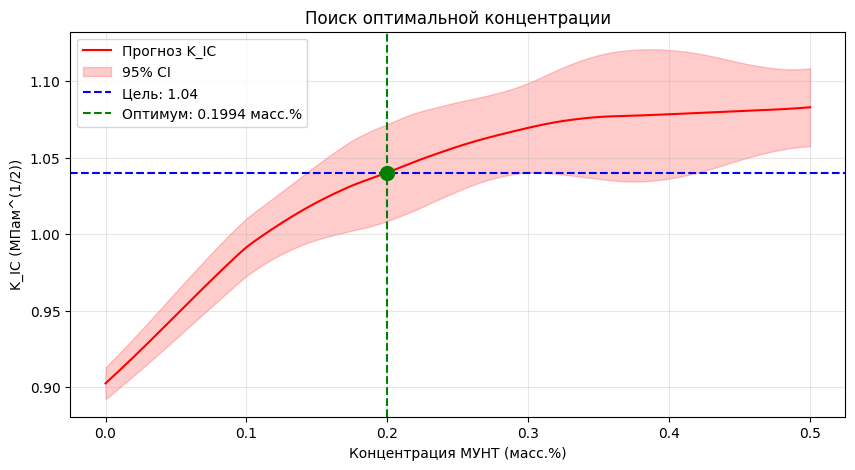

In [ ]:
recipe = concentration_calc(
    target_kic=1.04,
    scaler=scaler,
    models=best_models,
    df_full=df_full
)

In [ ]:
# Фактические значения
X_train1 = train_df[['a', 'c', 'P']].values
X_test1 = test_df[['a', 'c', 'P']].values

# Выбор 5000 случайных образцов из обучающей выборки
n_background = 5000
X_train_sample = shap.sample(X_train, n_background)

# Выбор 1000 образцов из тестовой выборки для анализа
n_test_sample = 1000
X_test_sample = shap.sample(X_test, n_test_sample)

X_test1 = shap.sample(X_test1, n_test_sample)

shap_mean = [] # список для хранения SHAP-значений всех моделей

for model in best_models:
    # Создание explainer
    explainer = shap.KernelExplainer(model, X_train_sample)

    # Расчет SHAP-значений
    shap_values = explainer.shap_values(X_test_sample)
    shap_values = np.array(shap_values).squeeze() # приводим к правильной форме

    shap_mean.append(shap_values)

# Усреднение SHAP-значений по ансамблю
shap_values = np.mean(shap_mean, axis=0)

/tmp/ipykernel_893/1161925296.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, plot_type="bar",


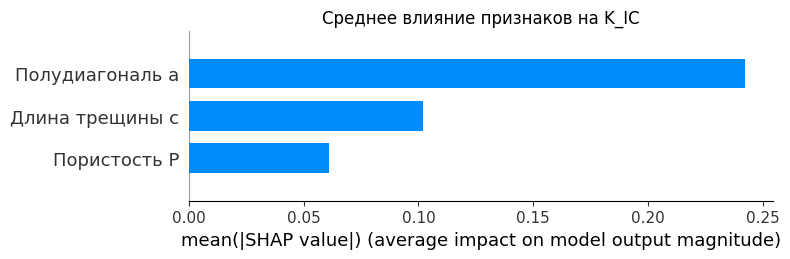

ОТНОСИТЕЛЬНАЯ ВАЖНОСТЬ ПРИЗНАКОВ:
   • Полудиагональ a: 59.8% от общего влияния на K_IC
   • Длина трещины c: 25.2% от общего влияния на K_IC
   • Пористость P: 15.1% от общего влияния на K_IC


In [ ]:
feature_names = ['Полудиагональ a', 'Длина трещины c', 'Пористость P']

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar",
        feature_names=feature_names,
        show=False,
        max_display=len(feature_names)
    )
plt.title('Среднее влияние признаков на K_IC', fontsize=12)
plt.tight_layout()

plt.show()

# Относительная важность
mean_shap = np.mean(np.abs(shap_values), axis=0)

print("ОТНОСИТЕЛЬНАЯ ВАЖНОСТЬ ПРИЗНАКОВ:")
total_impact = np.sum(np.abs(mean_shap))

for i, feature in enumerate(feature_names):
    relative_impact = np.abs(mean_shap[i]) / total_impact * 100
    print(f"   • {feature}: {relative_impact:.1f}% от общего влияния на K_IC")

По графику и расчетам видно, что наибольшее влияние на трещиностойкость оказывает полудиагональ отпечатка индентора, чуть меньшее - длина трещины, и еще меньше влияет пористость. Для более детального анализа был построен следующий график.

/tmp/ipykernel_893/161256510.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample,


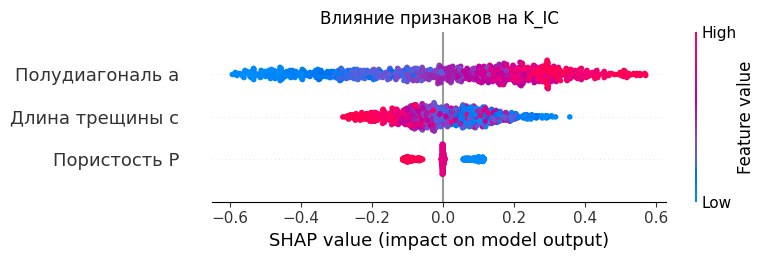

In [ ]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample,
        feature_names=feature_names,
        show=False,
        max_display=len(feature_names)
    )
plt.title('Влияние признаков на K_IC', fontsize=12)
plt.tight_layout()

plt.show()

На данном графике чем меньше значение признака, тем ближе цвет к синему, чем оно больше, тем ближе цвет к красному. Также по длине графика можно определить его влияние на целевую переменную.
- Полудиагональ a показывает большее влияние K_IC, так как график распределения длинее. По цвету можно определить, что при росте длины полудиагонали трещиностойкость увеличивается.
- Длина трещины c оказывает меньшее влияние на целевую переменную. При этом обладает обратной зависимостью: чем больше длина трещины, тем меньше трещиностойкость.
- Пористость P оказывает наименьшее влияние относительно других признаков. Этот признак также имеет обратное влияние на трещиностойкость: чем он меньше, тем она больше.   

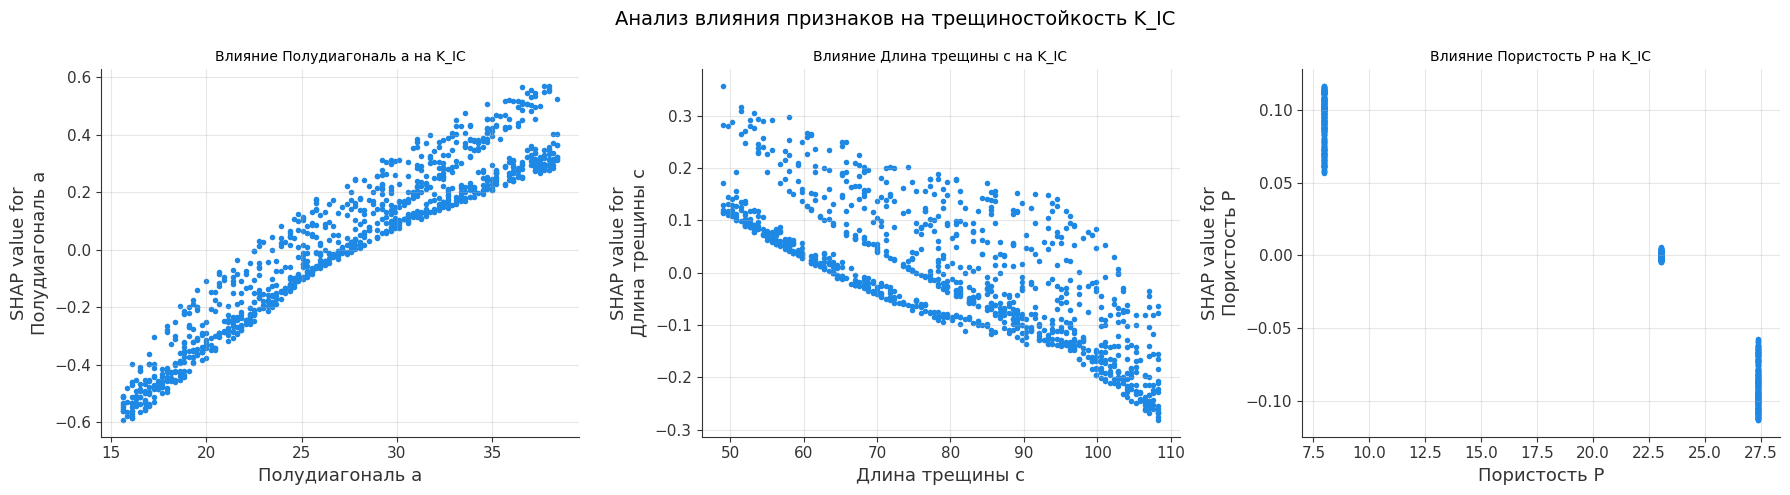

In [ ]:
n_features = len(feature_names)
fig, axes = plt.subplots(1, n_features, figsize=(6*n_features, 5))

if n_features == 1:
    axes = [axes]

for idx, feature in enumerate(feature_names):
    shap.dependence_plot(
        idx, shap_values, X_test1,
        feature_names=feature_names,
        ax=axes[idx], show=False,
        interaction_index=None
        )
    axes[idx].set_title(f'Влияние {feature} на K_IC', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Анализ влияния признаков на трещиностойкость K_IC', fontsize=14)
plt.tight_layout()

plt.show()

На данном графике наглядно видно, что при увеличении полудиагонали a трещиностойкость возрастает, а при увеличении длины трещины c и пористости P она уменьшается.

Выводы:

- Так как полудиагональ появляется в результате эксперимента, в котором на каждом образце выполнялись вдавливания алмазной пирамидой Виккерса, при большей трещиностойкости пирамида могла оставить больший след до появления трещин, поэтому можно наблюдать именно такое влияние признака a на целевую переменную.
- Длина трещины, полученная в результате, также зависит от трещиностойкости: чем она больше, тем меньше должны быть трещины.
- Поскольку пористость напрямую зависит от концентрации МУНТ в образце (чем больше концентрация МУНТ, тем меньше пористость), уменьшение значения пористости указывает на большую концентрацию МУНТ, следовательно, на большую трещиностойкость.